# CMAPSS RUL Prediction - Data Loading & Verification
This notebook contains the implementation of Fase 1: Data Loading of the development plan.

In [ ]:
import pandas as pd
import numpy as np
import os

## 1. Define Paths and Column Names

In [ ]:
# Define paths to data files
RAW_DATA_DIR = "../FD001_raw" # relative to preprocessing directory
TRAIN_PATH = os.path.join(RAW_DATA_DIR, "train_FD001.txt")
TEST_PATH = os.path.join(RAW_DATA_DIR, "test_FD001.txt")
RUL_PATH = os.path.join(RAW_DATA_DIR, "RUL_FD001.txt")

# Define column names based on CMAPSS dataset documentation
COLUMN_NAMES = [
    'unit_nr', 'time_cycles', 'op_1', 'op_2', 'op_3',
    's1', 's2', 's3', 's4', 's5', 's6', 's7', 's8', 's9', 's10',
    's11', 's12', 's13', 's14', 's15', 's16', 's17', 's18', 's19', 's20', 's21'
]

## 2. Load Datasets
Note: The raw data contains trailing spaces at the end of each line, which can result in extra NaN columns if not handled properly.
We will use `sep=r"\s+"` (regex separator for one or more whitespaces) to avoid extra NaN columns.

In [ ]:
# Load train and test datasets
train_df = pd.read_csv(TRAIN_PATH, sep=r"\s+", header=None, names=COLUMN_NAMES)
test_df = pd.read_csv(TEST_PATH, sep=r"\s+", header=None, names=COLUMN_NAMES)

# Load ground truth RUL for test set
rul_df = pd.read_csv(RUL_PATH, sep=r"\s+", header=None, names=['RUL'])

## 3. Verify Shape and Columns

In [ ]:
print(f"Train Shape: {train_df.shape}")
print(f"Test Shape: {test_df.shape}")
print(f"RUL Shape: {rul_df.shape}")

Train Shape: (20631, 26)
Test Shape: (13096, 26)
RUL Shape: (100, 1)


## 4. Display Head of Datasets

In [ ]:
print("Train Head:")
print(train_df.head())

Train Head:
   unit_nr  time_cycles    op_1    op_2   op_3      s1      s2       s3  \
0        1            1 -0.0007 -0.0004  100.0  518.67  641.82  1589.70   
1        1            2  0.0019 -0.0003  100.0  518.67  642.15  1591.82   
2        1            3 -0.0043  0.0003  100.0  518.67  642.35  1587.99   
3        1            4  0.0007  0.0000  100.0  518.67  642.35  1582.79   
4        1            5 -0.0019 -0.0002  100.0  518.67  642.37  1582.85   

        s4     s5  ...     s12      s13      s14     s15   s16  s17   s18  \
0  1400.60  14.62  ...  521.66  2388.02  8138.62  8.4195  0.03  392  2388   
1  1403.14  14.62  ...  522.28  2388.07  8131.49  8.4318  0.03  392  2388   
2  1404.20  14.62  ...  522.42  2388.03  8133.23  8.4178  0.03  390  2388   
3  1401.87  14.62  ...  522.86  2388.08  8133.83  8.3682  0.03  392  2388   
4  1406.22  14.62  ...  522.19  2388.04  8133.80  8.4294  0.03  393  2388   

     s19    s20      s21  
0  100.0  39.06  23.4190  
1  100.0  39.00  23.

In [ ]:
print("\nTest Head:")
print(test_df.head())


Test Head:
   unit_nr  time_cycles    op_1    op_2   op_3      s1      s2       s3  \
0        1            1  0.0023  0.0003  100.0  518.67  643.02  1585.29   
1        1            2 -0.0027 -0.0003  100.0  518.67  641.71  1588.45   
2        1            3  0.0003  0.0001  100.0  518.67  642.46  1586.94   
3        1            4  0.0042  0.0000  100.0  518.67  642.44  1584.12   
4        1            5  0.0014  0.0000  100.0  518.67  642.51  1587.19   

        s4     s5  ...     s12      s13      s14     s15   s16  s17   s18  \
0  1398.21  14.62  ...  521.72  2388.03  8125.55  8.4052  0.03  392  2388   
1  1395.42  14.62  ...  522.16  2388.06  8139.62  8.3803  0.03  393  2388   
2  1401.34  14.62  ...  521.97  2388.03  8130.10  8.4441  0.03  393  2388   
3  1406.42  14.62  ...  521.38  2388.05  8132.90  8.3917  0.03  391  2388   
4  1401.92  14.62  ...  522.15  2388.03  8129.54  8.4031  0.03  390  2388   

     s19    s20      s21  
0  100.0  38.86  23.3735  
1  100.0  39.02  23.

In [ ]:
print("\nRUL Head:")
print(rul_df.head())


RUL Head:
   RUL
0  112
1   98
2   69
3   82
4   91


## 5. Check Data Types and Missing Values

In [ ]:
print("Train Data Types and Missing Values:")
train_df.info()

Train Data Types and Missing Values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 26 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   unit_nr      20631 non-null  int64  
 1   time_cycles  20631 non-null  int64  
 2   op_1         20631 non-null  float64
 3   op_2         20631 non-null  float64
 4   op_3         20631 non-null  float64
 5   s1           20631 non-null  float64
 6   s2           20631 non-null  float64
 7   s3           20631 non-null  float64
 8   s4           20631 non-null  float64
 9   s5           20631 non-null  float64
 10  s6           20631 non-null  float64
 11  s7           20631 non-null  float64
 12  s8           20631 non-null  float64
 13  s9           20631 non-null  float64
 14  s10          20631 non-null  float64
 15  s11          20631 non-null  float64
 16  s12          20631 non-null  float64
 17  s13          20631 non-null  float64
 18  s14      

In [ ]:
print("\nTest Data Types and Missing Values:")
test_df.info()


Test Data Types and Missing Values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13096 entries, 0 to 13095
Data columns (total 26 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   unit_nr      13096 non-null  int64  
 1   time_cycles  13096 non-null  int64  
 2   op_1         13096 non-null  float64
 3   op_2         13096 non-null  float64
 4   op_3         13096 non-null  float64
 5   s1           13096 non-null  float64
 6   s2           13096 non-null  float64
 7   s3           13096 non-null  float64
 8   s4           13096 non-null  float64
 9   s5           13096 non-null  float64
 10  s6           13096 non-null  float64
 11  s7           13096 non-null  float64
 12  s8           13096 non-null  float64
 13  s9           13096 non-null  float64
 14  s10          13096 non-null  float64
 15  s11          13096 non-null  float64
 16  s12          13096 non-null  float64
 17  s13          13096 non-null  float64
 18  s14      

In [ ]:
print("\nMissing values count in Train:")
print(train_df.isnull().sum().sum())

print("\nMissing values count in Test:")
print(test_df.isnull().sum().sum())


Missing values count in Train:
0

Missing values count in Test:
0


## 6. Verify Unique Engines (unit_nr)

In [ ]:
num_train_units = train_df['unit_nr'].nunique()
num_test_units = test_df['unit_nr'].nunique()
num_rul_units = len(rul_df)

print(f"Number of unique engines in Train set: {num_train_units}")
print(f"Number of unique engines in Test set: {num_test_units}")
print(f"Number of engines in Ground Truth RUL set: {num_rul_units}")

assert num_train_units == 100, f"Expected 100 train units, found {num_train_units}"
assert num_test_units == 100, f"Expected 100 test units, found {num_test_units}"
assert num_rul_units == 100, f"Expected 100 ground truth units, found {num_rul_units}"
print("Verification successful! All checks passed.")

Number of unique engines in Train set: 100
Number of unique engines in Test set: 100
Number of engines in Ground Truth RUL set: 100
Verification successful! All checks passed.


# CMAPSS RUL Prediction - Fase 2: Exploratory Data Analysis (EDA)
In this phase, we analyze the characteristics of the sensors and operational settings to decide which features are informative and which are constant/noise.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

## 2a — Descriptive Statistics
We generate descriptive statistics for the sensor columns to identify columns with near-zero standard deviation (constant/not informative).

In [ ]:
# Describe sensor columns
sensor_cols = [col for col in train_df.columns if col.startswith('s')]
desc = train_df[sensor_cols].describe()
print(desc.transpose()[['mean', 'std', 'min', 'max']])

# Identify sensors with std near 0 (std < 0.01)
constant_sensors = desc.columns[desc.loc['std'] < 0.01].tolist()
print(f"\nSensors with std near 0 (almost constant): {constant_sensors}")

            mean           std        min        max
s1    518.670000  0.000000e+00   518.6700   518.6700
s2    642.680934  5.000533e-01   641.2100   644.5300
s3   1590.523119  6.131150e+00  1571.0400  1616.9100
s4   1408.933782  9.000605e+00  1382.2500  1441.4900
s5     14.620000  5.329200e-15    14.6200    14.6200
s6     21.609803  1.388985e-03    21.6000    21.6100
s7    553.367711  8.850923e-01   549.8500   556.0600
s8   2388.096652  7.098548e-02  2387.9000  2388.5600
s9   9065.242941  2.208288e+01  9021.7300  9244.5900
s10     1.300000  0.000000e+00     1.3000     1.3000
s11    47.541168  2.670874e-01    46.8500    48.5300
s12   521.413470  7.375534e-01   518.6900   523.3800
s13  2388.096152  7.191892e-02  2387.8800  2388.5600
s14  8143.752722  1.907618e+01  8099.9400  8293.7200
s15     8.442146  3.750504e-02     8.3249     8.5848
s16     0.030000  3.469531e-18     0.0300     0.0300
s17   393.210654  1.548763e+00   388.0000   400.0000
s18  2388.000000  0.000000e+00  2388.0000  238

**Temuan:**
Secara empiris pada dataset FD001, sensor berikut adalah konstan atau hampir konstan (std ≈ 0): `s1`, `s5`, `s6`, `s10`, `s16`, `s18`, `s19`. Sensor-sensor ini tidak membawa informasi tentang proses degradasi mesin, sehingga perlu di-drop pada tahap preprocessing.

## 2b — Degradation Trend Visualization
We visualize the values of informative sensors over cycles for a few select engine units to observe the degradation trends.

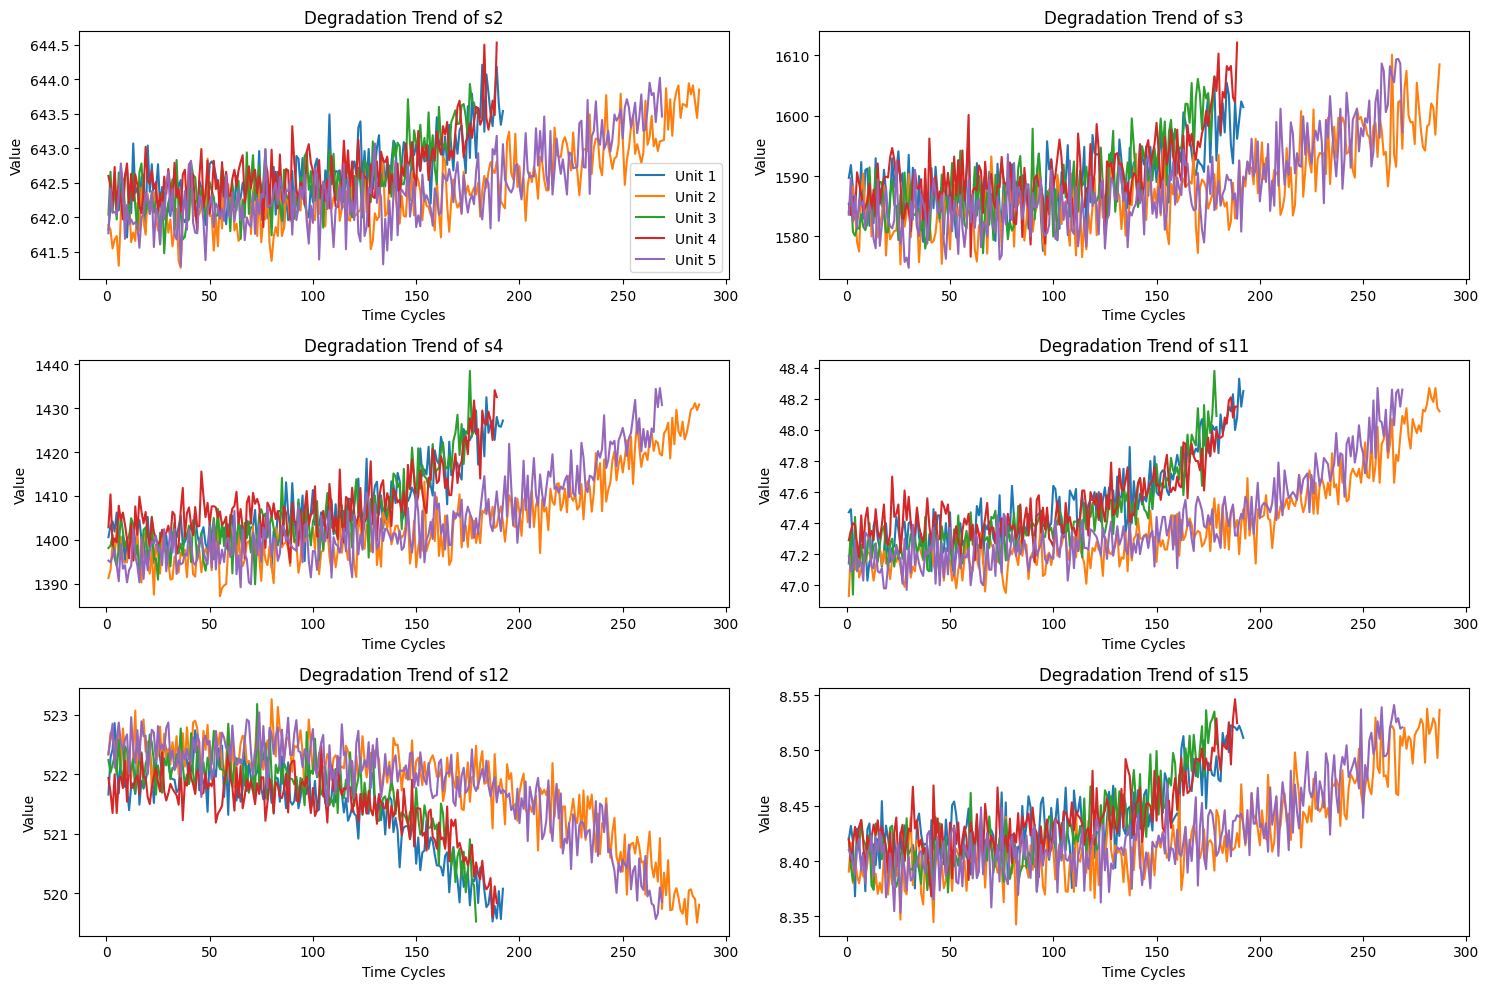

In [ ]:
# Select informative sensors to visualize
visualize_sensors = ['s2', 's3', 's4', 's11', 's12', 's15']
selected_units = [1, 2, 3, 4, 5]

plt.figure(figsize=(15, 10))
for i, sensor in enumerate(visualize_sensors, 1):
    plt.subplot(3, 2, i)
    for unit in selected_units:
        unit_data = train_df[train_df['unit_nr'] == unit]
        plt.plot(unit_data['time_cycles'], unit_data[sensor], label=f"Unit {unit}")
    plt.title(f"Degradation Trend of {sensor}")
    plt.xlabel("Time Cycles")
    plt.ylabel("Value")
    if i == 1:
        plt.legend()
plt.tight_layout()
plt.show()

**Temuan:**
Visualisasi menunjukkan tren degradasi yang monoton seiring bertambahnya siklus (time_cycles). 
- Beberapa sensor menunjukkan tren **meningkat** (seperti `s2`, `s3`, `s4`, `s11`, `s15`).
- Beberapa sensor menunjukkan tren **menurun** (seperti `s12`).
Ini mengonfirmasi bahwa pola sensor berkorelasi dengan degradasi kesehatan mesin, yang memungkinkan model untuk memprediksi sisa umur mesin (RUL).

## 2c — Time Series Length Distribution
We analyze the distribution of the maximum cycles (lifetime) for each engine in the training set.

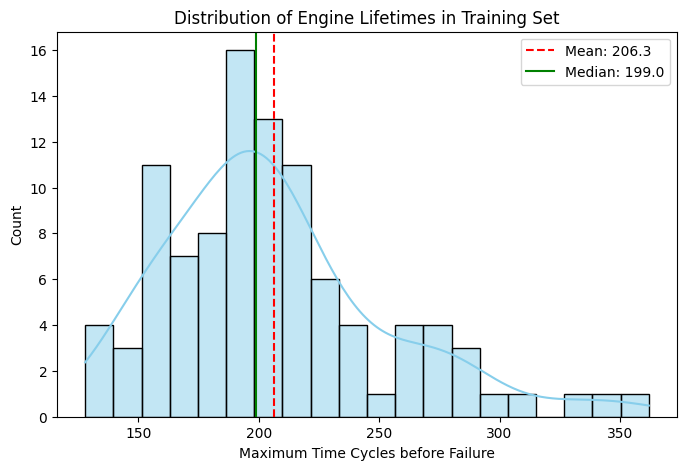

Minimum engine lifetime: 128 cycles
Maximum engine lifetime: 362 cycles


In [ ]:
# Group by unit_nr to get lifetime of each engine
lifetimes = train_df.groupby('unit_nr')['time_cycles'].max()

plt.figure(figsize=(8, 5))
sns.histplot(lifetimes, bins=20, kde=True, color='skyblue')
plt.axvline(lifetimes.mean(), color='red', linestyle='--', label=f"Mean: {lifetimes.mean():.1f}")
plt.axvline(lifetimes.median(), color='green', linestyle='-', label=f"Median: {lifetimes.median():.1f}")
plt.title("Distribution of Engine Lifetimes in Training Set")
plt.xlabel("Maximum Time Cycles before Failure")
plt.ylabel("Count")
plt.legend()
plt.show()

print(f"Minimum engine lifetime: {lifetimes.min()} cycles")
print(f"Maximum engine lifetime: {lifetimes.max()} cycles")

**Justifikasi Teknis untuk Clipping RUL (Piecewise RUL):**
Grafik distribusi panjang time series menunjukkan bahwa umur mesin berkisar dari 128 hingga 362 siklus. 
Pada masa awal operasi (misal ketika mesin baru beroperasi < 100 siklus), kondisi mesin masih prima dan sensor menunjukkan nilai yang stabil tanpa sinyal degradasi yang signifikan. 
Jika RUL didefinisikan secara linear penuh (misal RUL = 300 di awal), model regresi akan kesulitan mempelajari hubungan sensor dengan RUL karena sensor di awal (sehat) terlihat sama baik untuk mesin yang berumur 300 siklus maupun 150 siklus.

Oleh karena itu, kita menggunakan **clipping RUL** (misalnya di batas 125 siklus). RUL di awal operasi di-clip pada nilai 125. Saat mesin mulai terdegradasi (di bawah 125 siklus sebelum gagal), barulah RUL berkurang secara linear hingga mencapai 0. Ini sangat meningkatkan akurasi estimasi RUL.

## 2d — Sensor Correlation Analysis
We compute and plot the correlation matrix for the informative sensors to identify multicollinearity.

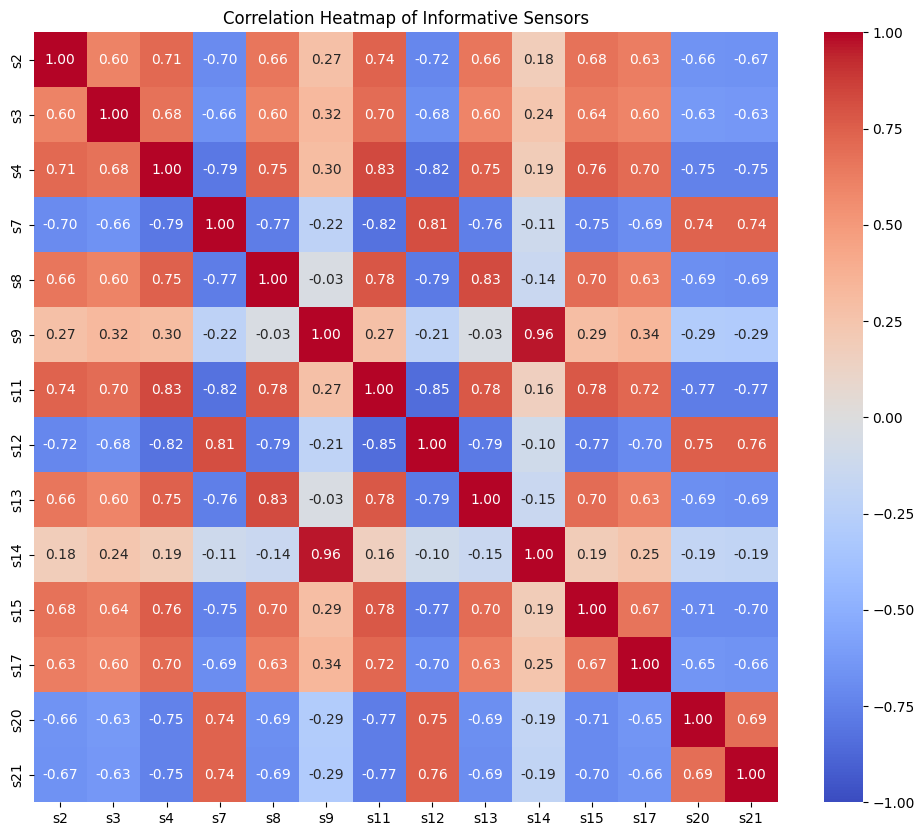

In [ ]:
# Filter out constant sensors
informative_sensors = [s for s in sensor_cols if s not in constant_sensors]

# Correlation heatmap
corr = train_df[informative_sensors].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation Heatmap of Informative Sensors")
plt.show()

## 2e — Operational Settings Distribution
We verify the distribution of the operational settings (op_1, op_2, op_3).

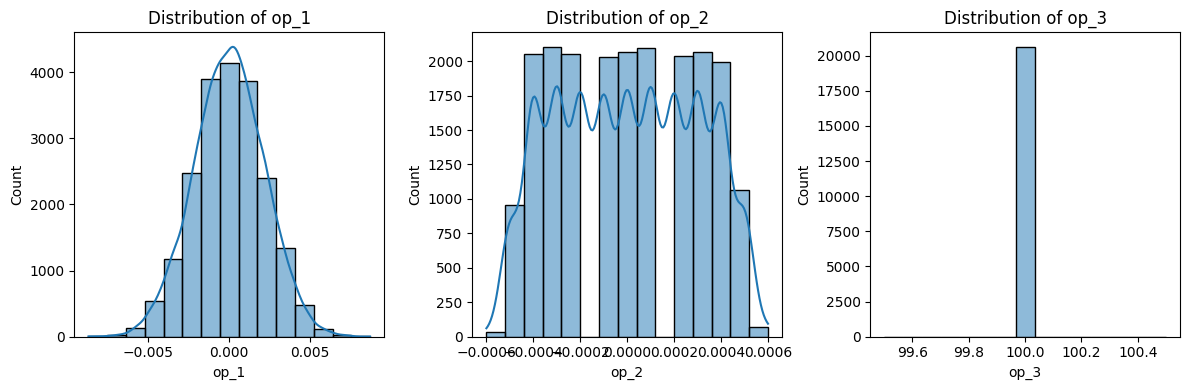

Unique values/Stats for op_1:
count    20631.000000
mean        -0.000009
std          0.002187
min         -0.008700
25%         -0.001500
50%          0.000000
75%          0.001500
max          0.008700
Name: op_1, dtype: float64
------------------------------
Unique values/Stats for op_2:
count    20631.000000
mean         0.000002
std          0.000293
min         -0.000600
25%         -0.000200
50%          0.000000
75%          0.000300
max          0.000600
Name: op_2, dtype: float64
------------------------------
Unique values/Stats for op_3:
count    20631.0
mean       100.0
std          0.0
min        100.0
25%        100.0
50%        100.0
75%        100.0
max        100.0
Name: op_3, dtype: float64
------------------------------


In [ ]:
op_cols = ['op_1', 'op_2', 'op_3']
plt.figure(figsize=(12, 4))
for i, op in enumerate(op_cols, 1):
    plt.subplot(1, 3, i)
    sns.histplot(train_df[op], kde=True, bins=15)
    plt.title(f"Distribution of {op}")
plt.tight_layout()
plt.show()

for op in op_cols:
    print(f"Unique values/Stats for {op}:")
    print(train_df[op].describe())
    print("-" * 30)

**Temuan:**
- Untuk dataset FD001, operational settings hampir konstan (hanya ada variasi kecil pada `op_1` dan `op_2`, sedangkan `op_3` adalah konstan 100.0). Hal ini mengonfirmasi bahwa FD001 beroperasi pada kondisi tunggal (single operating condition).